In [24]:
import sys
print(sys.executable)

C:\Users\Teaholic\anaconda3\envs\enzyme_mining\python.exe


In [18]:
import pandas as pd
import sys
from Bio import SeqIO
from pathlib import Path

#fasta_file = sys.argv[1]
fasta_file = "../data/proteomes/trichoderma_reesei_QM6a.fasta"

lengths = []
ids = []

for record in SeqIO.parse(fasta_file, "fasta"):
    ids.append(record.id)
    lengths.append(len(record.seq))

df = pd.DataFrame({
    "protein_id": ids,
    "length": lengths
})


stats = {
    "species": Path(fasta_file).stem,
    "number_of_proteins": len(df),
    "average_length": df["length"].mean(),
    "median_length": df["length"].median(),
    "max_length": df["length"].max(),
    "min_length": df["length"].min()    
}

pstats = pd.DataFrame([stats])

print("Number of proteins:", len(df))
print("Average length:", df["length"].mean())

for record in SeqIO.parse(fasta_file, "fasta"):
    print(record.id)
    print(len(record.seq))
    break

df.to_csv("N:\Jupiter_Projects\enzyme-genome-mining-course/results/protein_lengths.csv", index=False)
pstats.to_csv("N:\Jupiter_Projects\enzyme-genome-mining-course/results/proteome_stats.csv", index=False)

Number of proteins: 9115
Average length: 492.6358749314317
sp|G0R6T8|LP9A_HYPJQ
344


In [9]:
pstats

,number_of_proteins,average_length,median_length,max_length,min_length
0,9115,492.635875,409.0,20873,48


In [15]:
df.sort_values(by=['length'], ascending=False)

,protein_id,length
2505,tr|G0RTM6|G0RTM6_HYPJQ,20873
2572,tr|G0RUG7|G0RUG7_HYPJQ,16534
4218,tr|G0RCM3|G0RCM3_HYPJQ,5173
2687,tr|G0RVW2|G0RVW2_HYPJQ,4876
127,tr|G0RA23|G0RA23_HYPJQ,4373
...,...,...
9110,tr|G0RXQ4|G0RXQ4_HYPJQ,50
3683,tr|G0RAE4|G0RAE4_HYPJQ,50
7471,tr|G0RR71|G0RR71_HYPJQ,50
9104,tr|G0RXP7|G0RXP7_HYPJQ,50


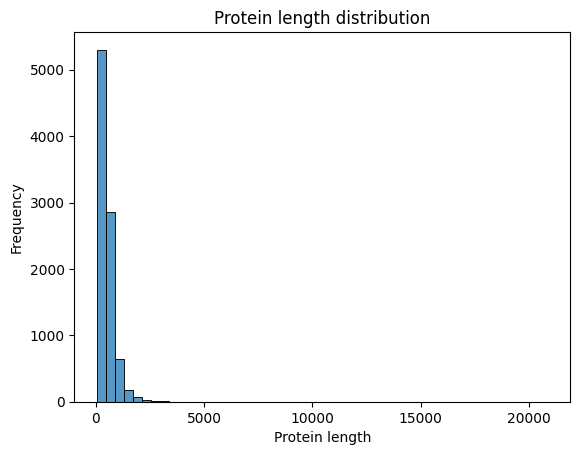

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["length"], bins=50)

plt.xlabel("Protein length")
plt.ylabel("Frequency")
plt.title("Protein length distribution")

plt.savefig("N:\Jupiter_Projects\enzyme-genome-mining-course/results/protein_length_distribution.png")

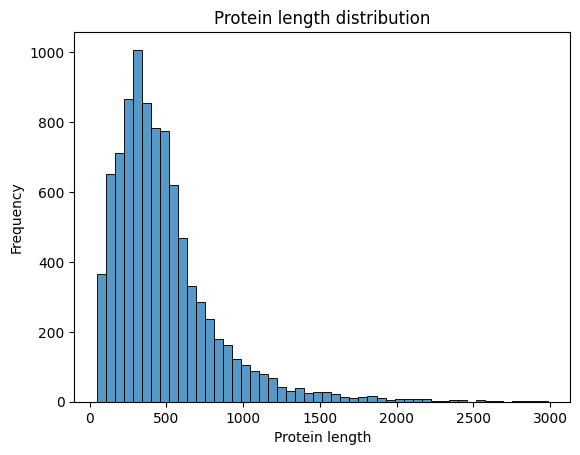

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df[df["length"] < 3000]["length"], bins=50)

plt.xlabel("Protein length")
plt.ylabel("Frequency")
plt.title("Protein length distribution")

plt.savefig("N:\Jupiter_Projects\enzyme-genome-mining-course/results/protein_length_distribution_clipped.png")

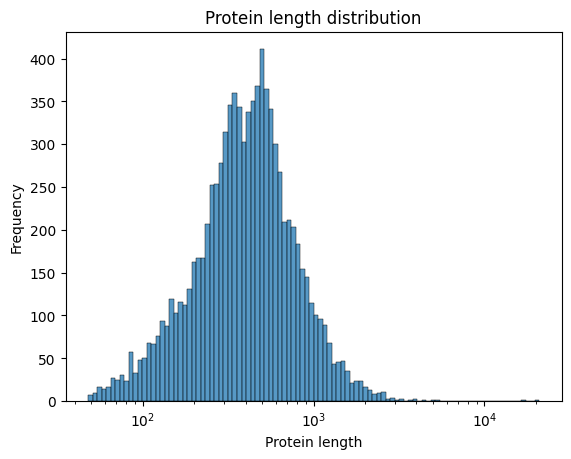

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["length"], bins=100, log_scale=True)

plt.xlabel("Protein length")
plt.ylabel("Frequency")
plt.title("Protein length distribution")

plt.savefig("N:\Jupiter_Projects\enzyme-genome-mining-course/results/protein_length_distribution_binned.png")

In [17]:
from pathlib import Path

species = Path(fasta_file).stem
print(species)

trichoderma_reesei_QM6a


In [20]:
import re

description = record.description
species = re.search(r'OS=(.*?)\sOX=', description).group(1)
print(species)

Hypocrea jecorina (strain QM6a)


In [22]:
df["length"].describe()

count     9115.000000
mean       492.635875
std        452.310698
min         48.000000
25%        263.000000
50%        409.000000
75%        601.000000
max      20873.000000
Name: length, dtype: float64